# Credit Risk ML Modelling using Random Forest

## Import Relevant Libraries

In [1]:
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
sns.set()

## Loading the Preprocessed Data

In [2]:
# load the preprocessed CSV data
data_preprocessed = pd.read_csv('data_preprocessed.csv')

## Dataset final preparation for modelling

In [3]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [4]:
display(data_preprocessed)

,Unnamed: 0,late_payments_90d,credit_history_years,oldest_account_age,hard_inquiries_last_6m,debt_to_income,credit_utilization,loan_to_income,delinquencies_last_12m,delinquency_ratio,utilization_to_income,default
0,0,0.000000,0.500000,6.313200,4.000000,0.424507,0.314964,0.372652,0.000000,0.000000,8.451952e-01,0
1,1,0.000000,8.980004,6.883349,3.000000,0.329260,0.421096,0.277712,0.000000,0.000000,1.516301e+00,0
2,2,0.000000,14.583410,10.945865,6.000000,0.447153,0.291516,0.179290,1.000000,0.100000,1.625934e+00,0
3,4,0.000000,2.592747,8.201624,1.000000,0.314877,0.071277,0.097128,0.000000,0.000000,7.338362e-01,0
4,5,0.000000,2.896384,15.043482,2.000000,0.314879,0.492659,0.277802,0.000000,0.000000,1.773413e+00,0
5,6,0.000000,7.839522,4.535441,0.000000,0.586882,0.450241,0.074629,0.000000,0.000000,6.032939e+00,0
6,7,1.000000,7.156408,6.216304,2.000000,0.465115,0.286582,0.331843,0.000000,0.000000,8.636045e-01,0
7,8,1.000000,5.147130,3.737974,0.000000,0.279579,0.581849,0.187312,1.000000,0.250000,3.106295e+00,0
8,9,0.000000,8.260213,8.413582,1.000000,0.431384,0.637514,0.082716,0.000000,0.000000,7.707142e+00,0
9,10,0.000000,0.500000,7.673156,0.000000,0.280487,0.128488,0.381670,0.000000,0.000000,3.366462e-01,0


In [5]:
data_preprocessed=data_preprocessed.drop('Unnamed: 0',axis=1)

In [6]:
data_preprocessed.head()

,late_payments_90d,credit_history_years,oldest_account_age,hard_inquiries_last_6m,debt_to_income,credit_utilization,loan_to_income,delinquencies_last_12m,delinquency_ratio,utilization_to_income,default
0,0.0,0.500000,6.313200,4.0,0.424507,0.314964,0.372652,0.0,0.0,0.845195,0
1,0.0,8.980004,6.883349,3.0,0.329260,0.421096,0.277712,0.0,0.0,1.516301,0
2,0.0,14.583410,10.945865,6.0,0.447153,0.291516,0.179290,1.0,0.1,1.625934,0
3,0.0,2.592747,8.201624,1.0,0.314877,0.071277,0.097128,0.0,0.0,0.733836,0
4,0.0,2.896384,15.043482,2.0,0.314879,0.492659,0.277802,0.0,0.0,1.773413,0


In [7]:
# To check if the dataset is balance
data_preprocessed['default'].sum() / data_preprocessed['default'].shape[0]

0.1845107503290917

In [8]:
data_with_targets=data_preprocessed.copy()
data_with_targets.head()

,late_payments_90d,credit_history_years,oldest_account_age,hard_inquiries_last_6m,debt_to_income,credit_utilization,loan_to_income,delinquencies_last_12m,delinquency_ratio,utilization_to_income,default
0,0.0,0.500000,6.313200,4.0,0.424507,0.314964,0.372652,0.0,0.0,0.845195,0
1,0.0,8.980004,6.883349,3.0,0.329260,0.421096,0.277712,0.0,0.0,1.516301,0
2,0.0,14.583410,10.945865,6.0,0.447153,0.291516,0.179290,1.0,0.1,1.625934,0
3,0.0,2.592747,8.201624,1.0,0.314877,0.071277,0.097128,0.0,0.0,0.733836,0
4,0.0,2.896384,15.043482,2.0,0.314879,0.492659,0.277802,0.0,0.0,1.773413,0


Dataset Splitting

In [9]:
x=data_with_targets.drop('default',axis=1)
y=data_with_targets['default']

In [10]:
# declare 4 variables for the split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)

In [11]:
# check the shape of the train inputs and targets
print (x_train.shape, y_train.shape)
print (x_test.shape, y_test.shape)

(3646, 10) (3646,)
(912, 10) (912,)


Scaling the Input Variables

In [12]:
scaler = StandardScaler()

In [13]:
scaler.fit(x_train)

StandardScaler()

In [14]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Modelling using Random Forest

In [15]:
rf= RandomForestClassifier(random_state=42)
rf.fit(x_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [16]:
# Predict classes
y_pred = rf.predict(x_test_scaled)

# Predict probabilities
y_prob = rf.predict_proba(x_test_scaled)[:,1]

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9013157894736842


In [18]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[735   6]
 [ 84  87]]


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       741
           1       0.94      0.51      0.66       171

    accuracy                           0.90       912
   macro avg       0.92      0.75      0.80       912
weighted avg       0.90      0.90      0.89       912



In [20]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9473486911160041


Probabilty Threshold adjustment for Random Forest

In [21]:
# Predict classes
y_probs = rf.predict_proba(x_test_scaled)[:,1]
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    
    y_pred_threshold = (y_probs>= t).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0) 
    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1"]
)

print(threshold_df)

    Threshold  Precision    Recall        F1
0        0.10   0.317490  0.976608  0.479197
1        0.15   0.463343  0.923977  0.617188
2        0.20   0.623482  0.900585  0.736842
3        0.25   0.760417  0.853801  0.804408
4        0.30   0.847561  0.812865  0.829851
5        0.35   0.898551  0.725146  0.802589
6        0.40   0.919355  0.666667  0.772881
7        0.45   0.935780  0.596491  0.728571
8        0.50   0.935484  0.508772  0.659091
9        0.55   0.957143  0.391813  0.556017
10       0.60   0.960784  0.286550  0.441441
11       0.65   0.975000  0.228070  0.369668
12       0.70   1.000000  0.169591  0.290000
13       0.75   1.000000  0.134503  0.237113
14       0.80   1.000000  0.070175  0.131148
15       0.85   1.000000  0.035088  0.067797


In [22]:
best_threshold = threshold_df.loc[threshold_df["F1"].idxmax()]

print(best_threshold)

Threshold    0.300000
Precision    0.847561
Recall       0.812865
F1           0.829851
Name: 4, dtype: float64


In [23]:
best_t = best_threshold["Threshold"]

y_pred_final = (y_probs >= best_t).astype(int)

In [24]:
accuracy = accuracy_score(y_test, y_pred_final)
print("Accuracy:", accuracy)

Accuracy: 0.9375


In [25]:
cm = confusion_matrix(y_test, y_pred_final)
print(cm)

[[716  25]
 [ 32 139]]


In [26]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       741
           1       0.85      0.81      0.83       171

    accuracy                           0.94       912
   macro avg       0.90      0.89      0.90       912
weighted avg       0.94      0.94      0.94       912



In [27]:
auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9473486911160041


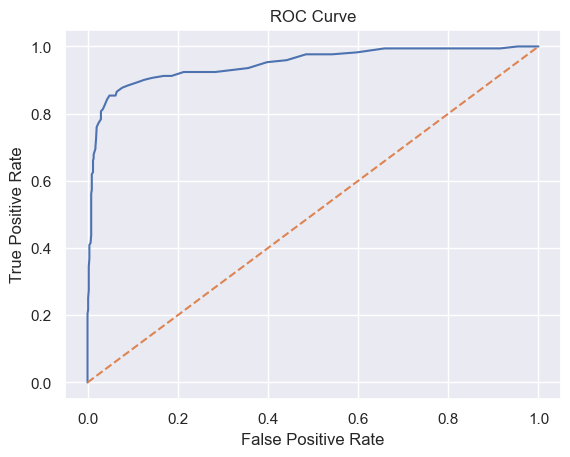

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Feature Importance Check

In [29]:
importance = rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

                  Feature  Importance
4          debt_to_income    0.133941
1    credit_history_years    0.129580
2      oldest_account_age    0.126094
6          loan_to_income    0.124021
5      credit_utilization    0.117552
9   utilization_to_income    0.111584
3  hard_inquiries_last_6m    0.071315
8       delinquency_ratio    0.069718
0       late_payments_90d    0.068465
7  delinquencies_last_12m    0.047729


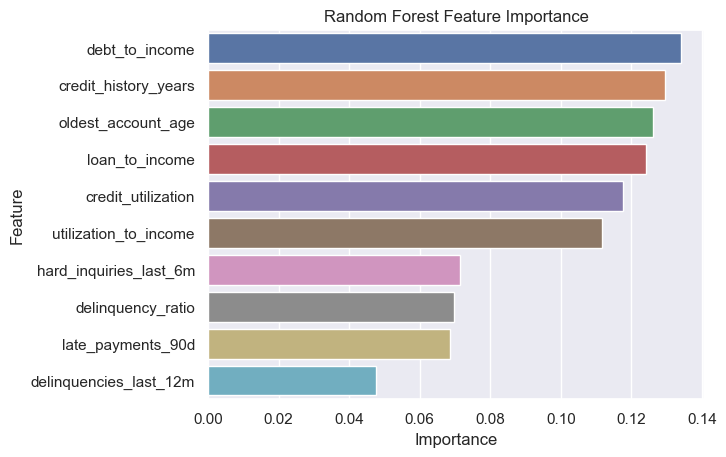

In [30]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.show()